<a href="https://colab.research.google.com/github/adit-codez/Assignment-04/blob/main/q2_customers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_excel("q2_customers.xlsx")

# Preview
print("Shape:", df.shape)
display(df.head())
print("Missing values:", df.isnull().sum())
print("Data types:", df.dtypes)

# Feature columns
features = [
    "age",
    "annual_spend",
    "visits_per_month",
    "basket_size",
    "days_since_last_visit",
    "num_categories_purchased"
]

X = df[features]

# Scale all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
display(X_scaled_df.head())

Shape: (500, 6)


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


Missing values: age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64
Data types: age                         int64
annual_spend                int64
visits_per_month            int64
basket_size                 int64
days_since_last_visit       int64
num_categories_purchased    int64
dtype: object


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


Scaling is essential before applying K-Means because the algorithm uses Euclidean distance to form clusters. If features are on very different scales, large-valued variables such as annual_spend or basket_size will dominate the distance calculation and distort the clustering result. StandardScaler puts all features on a comparable scale so each variable contributes fairly.

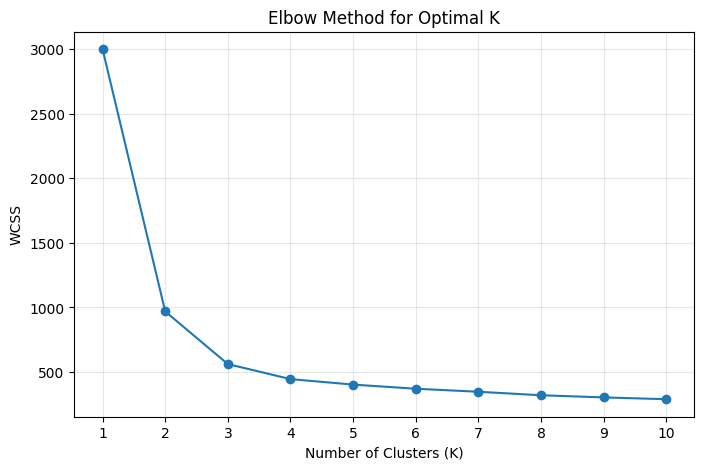

,K,WCSS
0,1,3000.000000
1,2,968.993871
2,3,561.253006
3,4,444.930276
4,5,402.371303
5,6,370.385393
6,7,346.954081
7,8,319.897475
8,9,303.282250
9,10,289.113979


In [2]:
# Elbow method
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.3)
plt.show()

elbow_df = pd.DataFrame({"K": range(1, 11), "WCSS": wcss})
display(elbow_df)

The elbow point is chosen where the WCSS starts decreasing more slowly after a strong initial drop. That point represents a good trade-off between compact clusters and model simplicity. I selected K = 3 based on the visible elbow in the plot, because adding more clusters after that gives only a small improvement.

In [3]:
# K-Means Clustering
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster counts:")
print(df["cluster"].value_counts().sort_index())

centroids_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=features)
display(centroids_scaled)

Cluster counts:
cluster
0    170
1    165
2    165
Name: count, dtype: int64


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.132214,1.235574,-1.106680,1.253260,1.125725,1.172991
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968


In [4]:
# Converting centroids to original scale
centroids_original = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
display(centroids_original)

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


### Cluster Interpretation

- Cluster 0 represents younger customers with lower spending and smaller baskets, suggesting occasional or low-value shoppers.
- Cluster 1 represents high-spending buyers with large basket sizes, suggesting regular loyal customers.
- Cluster 2 represents customers with large baskets but visitless and shop across fewer categories, likely stock-up shoppers.


In [5]:
# Dimensional Reduction with PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = df["cluster"]

loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=["PC1", "PC2"]
)
display(loadings)

Explained variance ratio: [0.83560354 0.05568764]
Total explained variance: 0.8912911772400688


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


PCA Interpretation

PC1 captures the strongest overall variation in the customer data, often separating customers by spending and engagement level.

PC2 captures a second, independent pattern, such as differences in shopping frequency versus recency. The loadings show which variables contribute most strongly to each component.

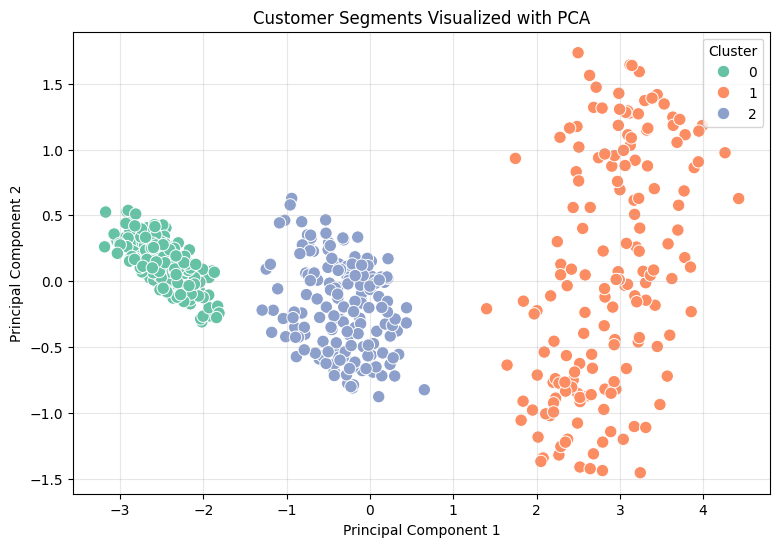

In [6]:
# Cluster Visualisation
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2",
    s=80
)

plt.title("Customer Segments Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True, alpha=0.3)
plt.show()